# Libraries

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import pyFAI
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.ticker import ScalarFormatter
from scipy.special import voigt_profile
import scipy
import os
import h5py
from scipy.signal import savgol_filter
from scipy.integrate import cumulative_trapezoid 
from scipy.special import voigt_profile
from numpy import trapz
pi = np.pi 
e = np.e 

# Functions for fit

In [46]:
def Monodisperse_spheres(x, scale, R, SLD_sphere, SLD_solvent, bkg): #Scattering of a single homogeneous sphere
    ro = SLD_sphere - SLD_solvent
    V = 4 * np.pi * R**3
    return (scale / V) * (3*V*ro*(np.sin(x*R)-x*R*np.cos(x*R))/(x*R)**3)**2 + bkg
    
def Gaussian(R, sigma, Ravg):
    return 1/(sigma * np.sqrt(2*np.pi)) * np.exp((-1/(2*sigma**2)) * (R-Ravg)**2)

def Polydisperse_spheres(x, scale, Ravg, p, bkg):
    global counter 
    global sigma
    sigma = p*Ravg
    #ro = scale
    R = np.arange(max((Ravg - 3*sigma), 0.00001), Ravg + 3*sigma, 0.05)
    Iq = []
    for i in x:
        f = (Gaussian(R, sigma, Ravg) * (R**6)) * ((3*(np.sin(i*R) - i*R*np.cos(i*R))/(i*R)**3)**2)
        Iq.append(scale* scipy.integrate.cumulative_trapezoid(f, R, dx = None, axis = 0)[-1] + bkg)
    #f = np.array(f)
    counter +=1
    return Iq

In [10]:
def asymmetric_gaussian(q, I0, q0, sigma, a):

    left = (q < q0)
    sigma_left = sigma * (1 + a)
    sigma_right = sigma * (1 - a)
    I = np.zeros_like(q)
    I[left] = I0 * np.exp(-(q[left] - q0)**2 / (2 * sigma_left**2))
    I[~left] = I0 * np.exp(-(q[~left] - q0)**2 / (2 * sigma_right**2))
    return I

def log_normal_peak(q, I0, q0, s):
    return I0 * np.exp(-(np.log(q / q0))**2 / (2 * s**2))

lnsp = np.linspace(1, 4, 1000)
Peak1 = log_normal_peak(lnsp, 10, 2, 0.1)
#plt.plot(lnsp, Peak1)

# Functions for plot


In [4]:
def SAXS_plot():
    plt.figure(figsize = (6,6))
    plt.semilogx()
    plt.semilogy()
    plt.xlim(0.045, 3)
    plt.legend()
    plt.xlabel('$q (nm^{-1})$')
    plt.ylabel('I (a.u.)')

# Data

In [5]:
def read_file(path):
    names = sorted(os.listdir(path))
    files = []
    
    for i in range(len(names)-1):
        files.append(path + '/' + names[i])

    return files

In [6]:
def read_exp_info(path):
    df = pd.read_csv(path, sep='\t', index_col=0)
    return df[['Time', 'Temperature', 'Crystalinity']]

In [11]:
Files_292_6_cryst_10C = read_file('E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_6_Cryst_at_10C\SAXS\INT')
Info_292_6_cryst_10C = read_exp_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\results_WAXS_cr\WAXS_PEG_PNIPAM_292_6_Cryst_at_10C.csv")
#plt.plot(Info_292_6_cryst_10C['Temperature'])

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\LabPC\AppData\Local\Temp\ipykernel_11176\1936535447.py:1: SyntaxWarning: invalid escape sequence '\P'
  Files_292_6_cryst_10C = read_file('E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_6_Cryst_at_10C\SAXS\INT')


# Analysis

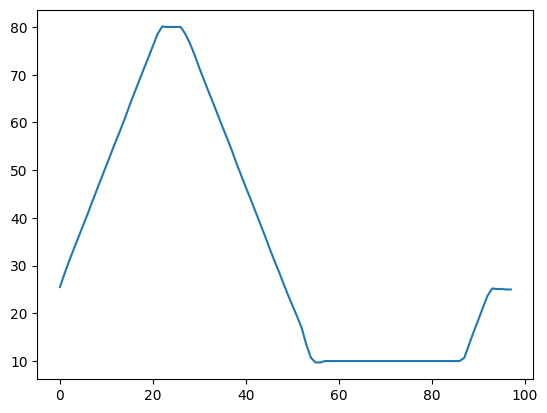

In [36]:
plt.plot(Info_292_6_cryst_10C['Temperature'])
counter = 0

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
C:\Users\LabPC\AppData\Local\Temp\ipykernel_11176\3513293118.py:5: SyntaxWarning: invalid escape sequence '\s'
  engine='python', skiprows=1, sep = '\s+', encoding='UTF-8')
C:\Users\LabPC\AppData\Local\Temp\ipykernel_11176\3513293118.py:12: SyntaxWarning: invalid escape sequence '\s'
  engine='python', skiprows=1, sep = '\s+', encoding='UTF-8')
C:\Users\LabPC\AppData\Local\Temp\ipykernel_11176\3485431038.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


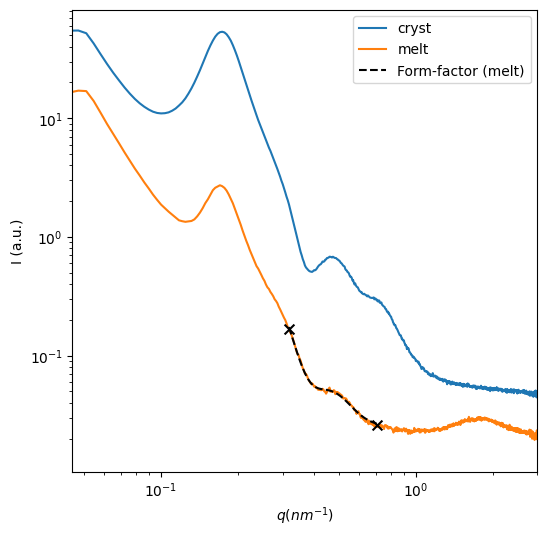

In [53]:
SAXS_plot()

# Crystall curve
curve = pd.read_table(Files_292_6_cryst_10C[80], header=None, names=['q', 'I', 'error'], 
                      engine='python', skiprows=1, sep = '\s+', encoding='UTF-8')
x = curve['q']
y = curve['I']
plt.plot(x, y*3, label='cryst')

# Melt curve
curve = pd.read_table(Files_292_6_cryst_10C[20], header=None, names=['q', 'I', 'error'], 
                      engine='python', skiprows=1, sep = '\s+', encoding='UTF-8')
x = curve['q']
y = curve['I']
plt.plot(x, y, label='melt')

# FF-analysis
l = 90
r = 200
plt.scatter(x[l], y[l], marker='x', color='black', s=50, zorder=10)
plt.scatter(x[r], y[r], marker='x', color='black', s=50, zorder=10)

model = Polydisperse_spheres
p0 = [1, 10, 0.1, 0.1]
p, cov = curve_fit(model, x[l:r], y[l:r], p0=p0)
plt.plot(x[l:r], model(x[l:r], *p), color='black', linestyle='--', label='Form-factor (melt)')
plt.legend()

In [54]:
p

array([2.54088800e-06, 1.07223797e+01, 1.72838170e-01, 2.13672321e-02])